# 1-1

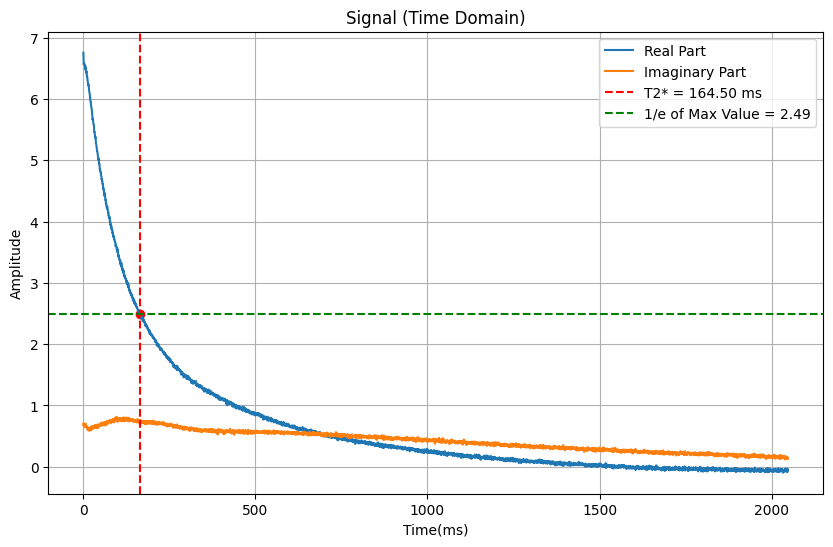

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read the CSV file
df = pd.read_csv('/Users/runzhaoguo/Documents/MQST-UCLA/411/Lab_Report_1/suppliment_data/1-1-on-t.csv', header=None)

# Extract real and imaginary parts
time_line = df.iloc[:, 0]
real_part = df.iloc[:, 1]  # First row as real part
imag_part = df.iloc[:, 2]  # Second row as imaginary part

max_value = np.max(real_part)
half_max = max_value / 2
indices_above_half_max = np.where(real_part >= half_max)[0]

if len(indices_above_half_max) > 0:
    start_index = indices_above_half_max[0]
    end_index = indices_above_half_max[-1]
else:
    raise ValueError("No values exceed half maximum. Cannot compute FWHM.")

# Calculate Signal Power (within FWHM)
signal_power = np.mean(real_part[start_index:end_index + 1] ** 2)

# Calculate Noise Power (outside FWHM)
noise_indices = np.concatenate((np.arange(0, start_index), np.arange(end_index + 1, len(real_part))))
noise_power = np.mean(real_part[noise_indices] ** 2) if len(noise_indices) > 0 else 1e-10  # Avoid division by zero

# Calculate SNR in dB
snr_db = 10 * np.log10(signal_power / noise_power)

# Plot the signal
plt.figure(figsize=(10, 6))
plt.plot(time_line, real_part, label='Real Part')
plt.plot(time_line, imag_part, label='Imaginary Part')

# Calculate the 1/e of the max value
one_over_e_value = max_value / np.e

# Find the index where the amplitude first drops below 1/e of the max value
t2_star_index = np.where(real_part <= one_over_e_value)[0][0]
t2_star_time = time_line[t2_star_index]

# Plot the point on the figure
plt.axvline(x=t2_star_time, color='r', linestyle='--', label=f'T2* = {t2_star_time:.2f} ms')
plt.axhline(y=one_over_e_value, color='g', linestyle='--', label=f'1/e of Max Value = {one_over_e_value:.2f}')
plt.scatter(t2_star_time, one_over_e_value, color='red')

plt.xlabel('Time(ms)')
plt.ylabel('Amplitude')
plt.title('Signal (Time Domain)')
plt.legend()
plt.grid(True)
plt.show()


# 1-4